# Em busca de uma situação-problema de ML nos dados do DECEA

O `01_explorar_aisweb.ipynb` mapeou as rotas da API. Este notebook usa os dados de verdade para responder: **que problema de machine learning / mineração de dados dá para resolver com eles?**

O primeiro obstáculo aparece logo: a AISWEB só mostra o **presente** (NOTAMs vigentes, o METAR mais recente). Modelo precisa de **histórico**. Por isso cruzei com mais duas fontes públicas:

| Fonte | O que tem | Acesso |
|---|---|---|
| **AISWEB** (DECEA) | NOTAMs vigentes, aeródromos, cartas | chave da API (`.env`) |
| **IEM** (Iowa State University) | METAR histórico de qualquer aeroporto do mundo | aberto, sem chave |
| **VRA** (ANAC) | todos os voos regulares: horário previsto e real, cancelamentos | aberto, um CSV por mês |

> A fonte **oficial** do DECEA para METAR/TAF histórico é a API da REDEMET (`api-redemet.decea.mil.br`), que exige chave própria (gratuita). O IEM espelha os mesmos boletins e serve para explorar; para o trabalho final vale pedir a chave da REDEMET.

## Resumo dos achados

1. **Clima ruim multiplica o atraso.** Com trovoada no aeroporto de origem, a taxa de voos com mais de 30 min de atraso vai de ~7,5% para ~18%. Abaixo dos mínimos de pouso ou com rajadas ≥ 25 kt, vai para ~25%, e o cancelamento fica 5× maior.
2. **Atraso se propaga.** A taxa de atraso cresce ao longo do dia (~3% nos primeiros voos da manhã, ~10% do fim da tarde à noite), e o atraso recente do aeroporto é a variável mais preditiva no modelo.
3. **Vento também conta.** Em 10/12/2025, uma ventania com rajadas de até 52 kt em Congonhas, sem chuva nem trovoada e com visibilidade de 10 km, cancelou 42% dos voos de lá e desorganizou a malha do país inteiro. Um modelo que só olha visibilidade e trovoada não enxerga esse dia.
4. **Nevoeiro e teto baixo têm padrão forte.** Guarulhos fica ~23% das horas em IMC, concentradas na madrugada e manhã; Curitiba, ~45%. Prever isso 3 h à frente dá AUC ~0,88, mas o baseline de "persistência" já é difícil de bater.
5. **Os NOTAMs têm códigos inconsistentes.** Metade das "ÁREAS PERIGOSAS TEMPORÁRIAS" está com código Q genérico (`XX`) em vez de `RD`. Um classificador de texto simples acerta o assunto com F1 ≈ 0,95.

A seção 9 junta tudo em situações-problema candidatas, com a recomendação.

## 1. Setup

In [2]:
import re

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, classification_report, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline, make_union

from module_decea.config import RAW_DATA_DIR
from module_decea.dataset import baixar_aisweb, baixar_metar_iem, baixar_vra
from module_decea.metar import carregar_iem
from module_decea.vra import carregar_vra, voos_regulares_domesticos

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 200)

In [3]:
# Estilo dos gráficos: paleta validada para daltonismo (azul, laranja, aqua) e cinza para contexto
AZUL, LARANJA, AQUA, CINZA = "#2a78d6", "#eb6834", "#1baf7a", "#c3c2b7"
TINTA, TINTA2, MUDO, GRADE, FUNDO = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
SEQ = LinearSegmentedColormap.from_list(
    "azul", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])

plt.rcParams.update({
    "figure.facecolor": FUNDO, "axes.facecolor": FUNDO, "savefig.facecolor": FUNDO,
    "axes.edgecolor": CINZA, "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRADE, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.titlepad": 10,
    "axes.labelcolor": TINTA2, "axes.labelsize": 10, "xtick.color": MUDO, "ytick.color": TINTA2,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "text.color": TINTA, "legend.frameon": False,
    "font.family": "sans-serif", "font.sans-serif": ["Helvetica Neue", "Arial", "DejaVu Sans"],
    "figure.dpi": 110,
})


def barras_h(ax, serie, cor=AZUL, fmt="{:.1f}", cores=None):
    """Barras horizontais com o valor escrito na ponta (a maior em cima)."""
    serie = serie.sort_values()
    barras = ax.barh(serie.index.astype(str), serie.values, color=cores if cores is not None else cor, height=0.62)
    for b, v in zip(barras, serie.values):
        ax.text(b.get_width(), b.get_y() + b.get_height() / 2, " " + fmt.format(v), va="center", fontsize=8.5, color=TINTA2)
    ax.grid(axis="y", visible=False)
    ax.set_xlim(0, serie.max() * 1.15)
    ax.tick_params(axis="y", length=0)
    return barras

## 2. Coleta (com cache em `data/raw/`)

Na primeira execução baixa tudo (~5 min, ~330 MB); depois só lê do disco. A pasta `data/` está no `.gitignore`.

- **AISWEB**: retrato do momento. O que está em `data/raw/aisweb/` foi baixado em **05/10/2026**. Para ter outro retrato, apague a pasta ou use `baixar_aisweb(forcar=True)`.
- **METAR**: ano de 2025 completo para os 10 aeroportos com mais partidas domésticas.
- **VRA**: os 12 meses de 2025.

In [4]:
AEROPORTOS = ["SBGR", "SBSP", "SBKP", "SBCF", "SBBR", "SBGL", "SBRJ", "SBPA", "SBCT", "SBRF"]
ANO = 2025

baixar_aisweb()
baixar_metar_iem(AEROPORTOS, ANO)
baixar_vra(ANO)

baixado: /Users/rodri/Desktop/Dev/faculdade/2026.2/Data_Mining/trabalho/Decea/data/raw/aisweb/localidades.csv
baixado: /Users/rodri/Desktop/Dev/faculdade/2026.2/Data_Mining/trabalho/Decea/data/raw/aisweb/notam.csv
baixado: /Users/rodri/Desktop/Dev/faculdade/2026.2/Data_Mining/trabalho/Decea/data/raw/aisweb/cartas.csv
baixado: /Users/rodri/Desktop/Dev/faculdade/2026.2/Data_Mining/trabalho/Decea/data/raw/aisweb/rotaer_lista.csv
baixado: /Users/rodri/Desktop/Dev/faculdade/2026.2/Data_Mining/trabalho/Decea/data/raw/metar/SBGR.csv
baixado: /Users/rodri/Desktop/Dev/faculdade/2026.2/Data_Mining/trabalho/Decea/data/raw/metar/SBSP.csv
baixado: /Users/rodri/Desktop/Dev/faculdade/2026.2/Data_Mining/trabalho/Decea/data/raw/metar/SBKP.csv
baixado: /Users/rodri/Desktop/Dev/faculdade/2026.2/Data_Mining/trabalho/Decea/data/raw/metar/SBCF.csv
baixado: /Users/rodri/Desktop/Dev/faculdade/2026.2/Data_Mining/trabalho/Decea/data/raw/metar/SBBR.csv
baixado: /Users/rodri/Desktop/Dev/faculdade/2026.2/Data_Mini

## 3. NOTAMs: o que está vigente agora

Cada NOTAM tem um **código Q** de 5 letras. As letras 2–3 dizem o **assunto** (pista, obstáculo, área restrita...) e as 4–5 a **condição** (fechado, fora de serviço, ativado...).

In [5]:
notam = pd.read_csv(RAW_DATA_DIR / "aisweb/notam.csv", dtype=str)
notam["assunto"] = notam["cod"].str[1:3]
notam["condicao"] = notam["cod"].str[3:5]
notam["inicio"] = pd.to_datetime(notam["b"], format="%y%m%d%H%M", errors="coerce")
notam["fim"] = pd.to_datetime(notam["c"], format="%y%m%d%H%M", errors="coerce")
notam["vigencia_dias"] = (notam["fim"] - notam["inicio"]).dt.total_seconds() / 86400

print(f"{len(notam)} NOTAMs vigentes | {notam['cod'].nunique()} códigos Q | {notam['assunto'].nunique()} assuntos")
print(f"{notam['icaoairport_id'].isna().sum()} sem aeródromo (são de espaço aéreo / FIR)")
print(f"{(notam['tp'] == 'NOTAMR').mean():.0%} são substituições (NOTAMR) de um NOTAM anterior")
notam["cat"].value_counts().rename("NOTAMs por categoria").to_frame().T

1775 NOTAMs vigentes | 127 códigos Q | 66 assuntos
406 sem aeródromo (são de espaço aéreo / FIR)
33% são substituições (NOTAMR) de um NOTAM anterior


cat,NAV,AGA,OTR,ATM,CNS
NOTAMs por categoria,1010,323,250,122,69


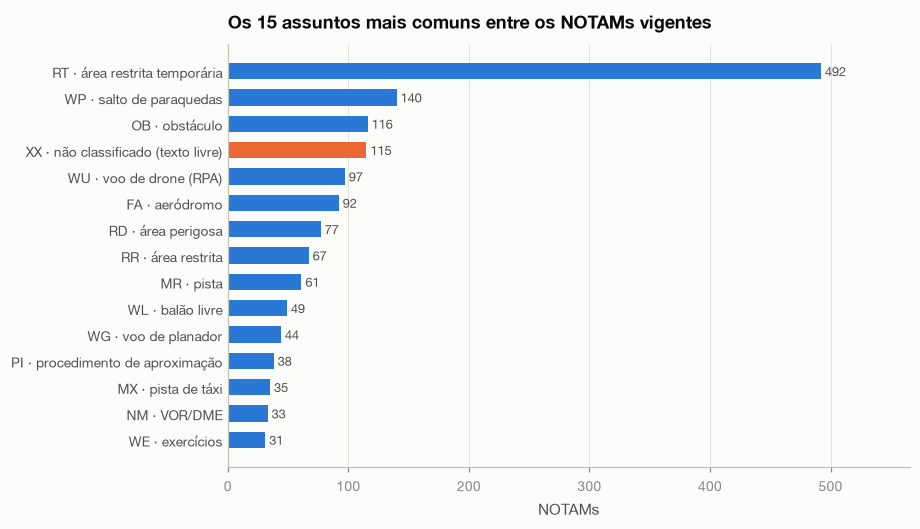

In [6]:
# Significado dos assuntos mais comuns (ICAO Doc 8126)
ASSUNTOS = {
    "RT": "área restrita temporária", "WP": "salto de paraquedas", "OB": "obstáculo",
    "XX": "não classificado (texto livre)", "WU": "voo de drone (RPA)", "FA": "aeródromo",
    "RD": "área perigosa", "RR": "área restrita", "MR": "pista", "WL": "balão livre",
    "WG": "voo de planador", "PI": "procedimento de aproximação", "MX": "pista de táxi",
    "NM": "VOR/DME", "WE": "exercícios", "LP": "PAPI", "SF": "serviço de informação de voo (AFIS)",
    "FM": "serviço meteorológico", "FF": "contraincêndio e salvamento",
}
top = notam["assunto"].value_counts().head(15)
top.index = [f"{q} · {ASSUNTOS.get(q, '')}" for q in top.index]

fig, ax = plt.subplots(figsize=(8, 5))
barras_h(ax, top, fmt="{:.0f}", cores=[LARANJA if i.startswith("XX") else AZUL for i in top.sort_values().index])
ax.set_title("Os 15 assuntos mais comuns entre os NOTAMs vigentes")
ax.set_xlabel("NOTAMs")
plt.show()

**Leitura:** quase um terço dos NOTAMs é de **área restrita temporária** (`RT`), quase todos do tipo "PJE" (salto de paraquedas em área militar). Pista, obstáculo e drone vêm logo atrás. Em laranja, o assunto `XX` ("não classificado"): **115 NOTAMs** sem assunto definido.

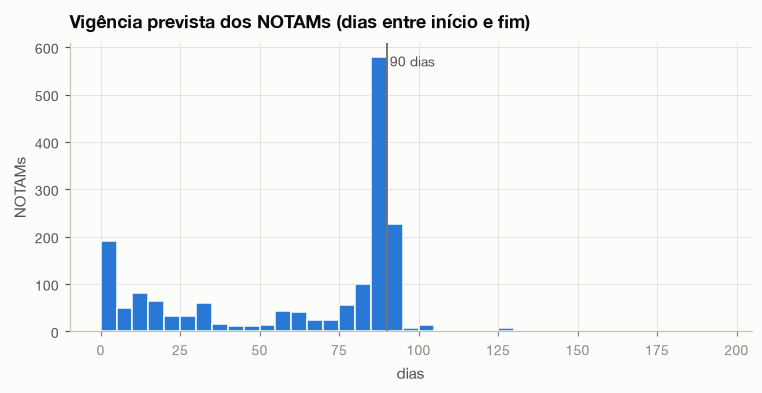

PERM (permanente): 4.6% | vigência acima de 90 dias: 2.9%


In [7]:
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.hist(notam["vigencia_dias"].dropna(), bins=np.arange(0, 200, 5), color=AZUL, edgecolor=FUNDO, linewidth=1)
ax.axvline(90, color=TINTA2, linewidth=1)
ax.text(91, ax.get_ylim()[1] * 0.92, "90 dias", color=TINTA2, fontsize=9)
ax.set_title("Vigência prevista dos NOTAMs (dias entre início e fim)")
ax.set_xlabel("dias")
ax.set_ylabel("NOTAMs")
plt.show()
print(f"PERM (permanente): {notam['c'].str.contains('PERM', na=False).mean():.1%} | "
      f"vigência acima de 90 dias: {(notam['vigencia_dias'] > 92).mean():.1%}")

**Leitura:** a vigência se amontoa logo antes de **90 dias**. É a regra do Anexo 15 da ICAO: informação que vai durar mais de 3 meses deveria virar suplemento da AIP, não NOTAM. Os poucos que passam disso (e os `PERM`) são candidatos naturais a uma auditoria.

### 3.1 Inconsistência na codificação

Se o texto começa com "ÁREA PERIGOSA TEMPORARIAMENTE", o assunto deveria ser `RD` (área perigosa). Vejamos o que acontece na prática:

In [8]:
texto = notam["e"].str.upper()
prefixos = {"AREA RESTRITA": "RT/RR esperado", "AREA PERIGOSA": "RD esperado", "AREA PROIBIDA": "RP esperado"}
pd.DataFrame({
    f"{p} ({esperado})": notam.loc[texto.str.startswith(p), "assunto"].value_counts()
    for p, esperado in prefixos.items()
}).fillna(0).astype(int)

,AREA RESTRITA (RT/RR esperado),AREA PERIGOSA (RD esperado),AREA PROIBIDA (RP esperado)
assunto,,,
RD,0,63,2
RT,492,0,0
XX,0,63,28


**Leitura:** "área restrita" é sempre codificada certo (`RT`). Já "área perigosa" sai **metade `RD`, metade `XX`**, e "área proibida" quase sempre `XX`. O mesmo tipo de informação recebe códigos diferentes conforme quem emite, e isso quebra qualquer filtro automático que dependa do código Q (é assim que sistemas de briefing decidem o que mostrar ao piloto).

### 3.2 Teste rápido: um classificador acerta o assunto pelo texto?

TF-IDF de palavras e de pedaços de palavras + regressão logística, validação cruzada em 5 partes. Os NOTAMs `XX` ficam fora do treino e são reclassificados no final. Textos repetidos (o NOTAMR costuma copiar o texto do original) entram uma vez só, para não inflar o resultado.

In [9]:
def limpar(t):
    return re.sub(r"\d+[.,]?\d*", " 0 ", t.upper())  # números viram um token só


unicos = notam.drop_duplicates("e")
rotulados = unicos[unicos["assunto"] != "XX"].copy()
frequentes = rotulados["assunto"].value_counts().loc[lambda s: s >= 10].index
rotulados["y"] = rotulados["assunto"].where(rotulados["assunto"].isin(frequentes), "OUTROS")
print(f"{len(unicos)} textos únicos | {len(rotulados)} rotulados | {rotulados['y'].nunique()} classes")

clf_notam = make_pipeline(
    make_union(TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True),
               TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=2, sublinear_tf=True)),
    LogisticRegression(max_iter=3000, C=10, class_weight="balanced"),
)
X = rotulados["e"].map(limpar)
pred = cross_val_predict(clf_notam, X, rotulados["y"], cv=StratifiedKFold(5, shuffle=True, random_state=0))
print(f"F1-macro = {f1_score(rotulados['y'], pred, average='macro'):.3f} "
      f"(chutar sempre a classe mais comum acerta {rotulados['y'].value_counts(normalize=True).iloc[0]:.0%})")
pd.DataFrame(classification_report(rotulados["y"], pred, output_dict=True, zero_division=0)).T.round(2).head(20)

819 textos únicos | 781 rotulados | 20 classes
F1-macro = 0.951 (chutar sempre a classe mais comum acerta 19%)


,precision,recall,f1-score,support
FA,0.85,0.87,0.86,47.0
FF,1.00,1.00,1.00,15.0
FM,1.00,1.00,1.00,16.0
LP,1.00,1.00,1.00,20.0
MB,0.92,1.00,0.96,11.0
MR,0.90,0.88,0.89,60.0
MX,0.92,0.94,0.93,35.0
ND,0.92,1.00,0.96,11.0
NM,0.95,1.00,0.98,21.0
OA,1.00,1.00,1.00,10.0


In [10]:
clf_notam.fit(X, rotulados["y"])
xx = unicos[unicos["assunto"] == "XX"]
sugestao = pd.DataFrame({"assunto sugerido": clf_notam.predict(xx["e"].map(limpar)), "texto": xx["e"].str[:110]})
display(sugestao["assunto sugerido"].value_counts().rename("NOTAMs XX").to_frame().T)
sugestao.head(12)

assunto sugerido,OUTROS,RD,MX,FM
NOTAMs XX,19,16,2,1


,assunto sugerido,texto
70,MX,"PONTO DE VERIFICACAO DE RECEPTOR NO SOLO VOR/DME BEL TWY BRAVO, DELTA U/S"
91,RD,AREA PERIGOSA TEMPORARIAMENTE (ASCENSAO BALAO LIVRE ESTRATOSFERICO) SUBJ AUTH/COOR CTR BRASILIA CENTRO COORD 1
92,RD,AREA PERIGOSA TEMPORARIAMENTE (EXER - VOO DE PARAMOTORES) SUBJ AUTH/COOR APP BRASILIA WI COORD 155715.33S/0475
93,RD,AREA PERIGOSA TEMPORARIAMENTE (EXER PARAMOTOR) SUBJ AUTH/COOR APP BRASILIA WI COORD 155652S0475947W - 155857S0
148,RD,AREA PERIGOSA TEMPORARIAMENTE (BALONISMO) SUBJ AUTH/COOR APP UBERLANDIA/TWR UBERLANDIA ACONTECERA CENTRO COORD
155,RD,AREA PERIGOSA TEMPORARIAMENTE (EXER - VOO DE ULTRALEVE) WI COORD 212125.49S0464511.34W - 211804.24S0464458.55W
159,RD,AREA PERIGOSA TEMPORARIAMENTE (EXER FLT DE ULTRALEVE MOTORIZADO) SUBJ AUTH ACC BRASILIA WI COORD 204001.78S046
162,RD,AREA PERIGOSA TEMPORARIAMENTE (BALONISMO) SUBJ AUTH/COOR APP ACADEMIA CENTRO COORD 224101.04S/0474551.70W RAIO
172,RD,"AREA PERIGOSA TEMPORARIAMENTE (SHOW PIROTECNICO - NUBANK PARQUE, SP) CENTRO COORD 233138.27S/0464042.49W RAIO"
182,OUTROS,ZONA DE INFORMACAO DE VOO (FIZ ARARAQUARA) BDRY VER SUPERIOR MODIFICADO DE 5000FT AMSL PARA 5500FT AMSL. \nREF:


**Leitura:** o classificador acerta muito (F1 ≈ 0,95) e reclassifica as "áreas perigosas" `XX` como `RD`, que é o certo. Ou seja, **é viável**, mas tem dois poréns para um trabalho:

- o texto é padronizado demais, então a tarefa é quase fácil demais para virar o problema principal;
- são só ~800 textos únicos. Daria para coletar a rota `notam` todo dia por algumas semanas para aumentar a base.

Funciona bem como **problema secundário**, ou se for ampliado: por exemplo, ordenar os NOTAMs por relevância para um voo específico, que é o problema real conhecido como *NOTAM overload*.

## 4. Aeródromos e infraestrutura

In [11]:
ad = pd.read_csv(RAW_DATA_DIR / "aisweb/rotaer_lista.csv", dtype=str)
ad["lat"], ad["lng"] = ad["lat"].astype(float), ad["lng"].astype(float)
cartas = pd.read_csv(RAW_DATA_DIR / "aisweb/cartas.csv", dtype=str)
com_iac = set(cartas.loc[cartas["tipo"] == "IAC", "IcaoCode"])
ad["procedimento_ifr"] = ad["AeroCode"].isin(com_iac)

print(f"{len(ad)} localidades no ROTAER: {ad['type'].value_counts().to_dict()} (AD aeródromo, HP heliponto)")
print(f"Só {ad['procedimento_ifr'].sum()} têm carta de aproximação por instrumentos (IAC); "
      f"o resto opera só em condição visual.")
ad.groupby("uf").agg(aerodromos=("type", lambda s: (s == "AD").sum()), helipontos=("type", lambda s: (s == "HP").sum()),
                     com_ifr=("procedimento_ifr", "sum")).sort_values("aerodromos", ascending=False).head(10).T

6123 localidades no ROTAER: {'AD': 4488, 'HP': 1626, 'HD': 9} (AD aeródromo, HP heliponto)
Só 176 têm carta de aproximação por instrumentos (IAC); o resto opera só em condição visual.


uf,MT,MS,BA,PA,SP,MG,GO,TO,RS,RR
aerodromos,1036,672,334,320,320,299,278,146,142,142
helipontos,4,6,87,14,633,178,64,6,35,1
com_ifr,7,6,13,9,22,15,4,2,9,3


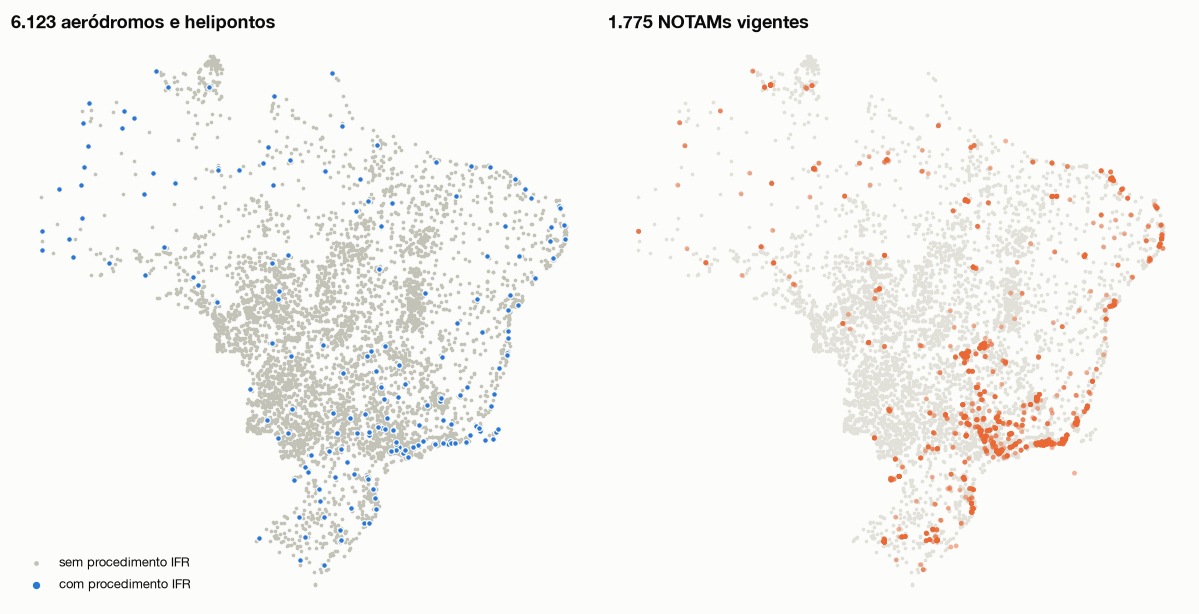

In [12]:
# Coordenada do NOTAM: "1707S04911W014" = 17°07'S, 049°11'W, raio de 14 NM
g = notam["geo"].str.extract(r"(\d{2})(\d{2})([NS])(\d{3})(\d{2})([EW])(\d{3})")
notam["lat"] = (g[0].astype(float) + g[1].astype(float) / 60) * np.where(g[2] == "S", -1, 1)
notam["lng"] = (g[3].astype(float) + g[4].astype(float) / 60) * np.where(g[5] == "W", -1, 1)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 5.6), sharex=True, sharey=True)
a1.scatter(ad["lng"], ad["lat"], s=2, color=CINZA, label="sem procedimento IFR")
ifr = ad[ad["procedimento_ifr"]]
a1.scatter(ifr["lng"], ifr["lat"], s=14, color=AZUL, edgecolor=FUNDO, linewidth=0.8, label="com procedimento IFR")
a1.set_title(f"{len(ad):,} aeródromos e helipontos".replace(",", "."))
a1.legend(loc="lower left", fontsize=8.5, markerscale=1.5)
a2.scatter(ad["lng"], ad["lat"], s=2, color=GRADE)
a2.scatter(notam["lng"], notam["lat"], s=10, color=LARANJA, alpha=0.5, edgecolor="none")
a2.set_title(f"{len(notam):,} NOTAMs vigentes".replace(",", "."))
for a in (a1, a2):
    a.set_aspect("equal")
    a.set_xlim(-75, -33)
    a.set_ylim(-34.5, 6)
    a.grid(False)
    a.set_xticks([])
    a.set_yticks([])
    for s in a.spines.values():
        s.set_visible(False)
plt.tight_layout()
plt.show()

**Leitura:** a malha de aeródromos é densa no Centro-Oeste e em SP (Mato Grosso tem mais de 1.000, quase todos pistas privadas do agronegócio), mas só 176 aeródromos têm procedimento de aproximação por instrumentos. Os NOTAMs se aglomeram no eixo SP–RJ–BH–Brasília.

Dá para fazer **mineração** aqui (agrupar aeródromos por perfil de infraestrutura e de NOTAMs), mas sem uma variável-alvo clara fica difícil fechar um "problema" com começo, meio e fim.

## 5. Clima: METAR de 2025 nos 10 maiores aeroportos

O módulo `module_decea/metar.py` decodifica cada boletim: visibilidade, **teto** (camada BKN/OVC mais baixa), vento, rajada e fenômenos (trovoada, nevoeiro, chuva). Duas flags derivadas:

- **IMC**: visibilidade < 5 km ou teto < 1.500 ft, ou seja, abaixo das condições de voo visual (ICA 100-12). O voo continua, mas por instrumentos e com menos capacidade de pistas.
- **Abaixo dos mínimos**: visibilidade < 800 m ou teto < 200 ft. Em geral fecha o aeroporto para pouso (~mínimos ILS CAT I).

Os SPECIs (boletins extras emitidos quando o tempo muda) ficam fora. Só os METARs de hora cheia entram, para não contar duas vezes as horas de tempo ruim.

In [13]:
metar = pd.concat([carregar_iem(RAW_DATA_DIR / f"metar/{icao}.csv") for icao in AEROPORTOS], ignore_index=True)
metar = metar[~metar["speci"]].copy()
metar["hora_local"] = (metar["hora_utc"] - pd.Timedelta(hours=3)).dt.hour
metar["mes"] = metar["hora_utc"].dt.month
print(f"{len(metar):,} METARs horários".replace(",", "."))
metar[["icao", "hora_utc", "vis_m", "teto_ft", "vento_kt", "rajada_kt", "trovoada", "nevoeiro", "imc", "abaixo_minimos"]].sample(5, random_state=1)

87.593 METARs horários


,icao,hora_utc,vis_m,teto_ft,vento_kt,rajada_kt,trovoada,nevoeiro,imc,abaixo_minimos
62182,SBRJ,2025-07-31 21:00:00,9999.0,99999,8.0,NaN,False,False,False,False
30232,SBCF,2025-01-15 22:00:00,9999.0,3000,9.0,NaN,False,False,False,False
70122,SBPA,2025-06-11 10:00:00,4000.0,300,3.0,NaN,False,False,True,False
63489,SBRJ,2025-09-23 03:00:00,8000.0,10000,9.0,NaN,False,False,False,False
3335,SBGR,2025-05-10 02:00:00,9999.0,99999,2.0,NaN,False,False,False,False


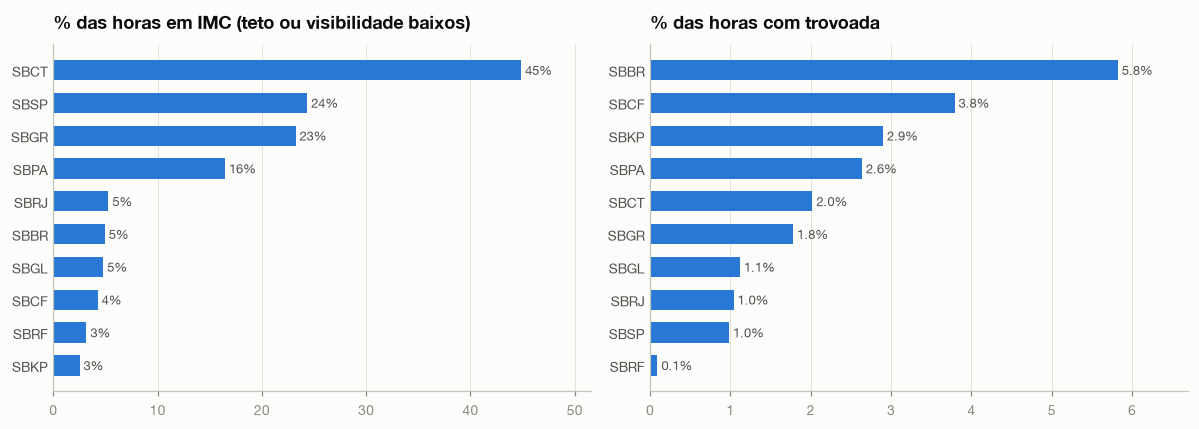

In [14]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
barras_h(a1, metar.groupby("icao")["imc"].mean() * 100, fmt="{:.0f}%")
a1.set_title("% das horas em IMC (teto ou visibilidade baixos)")
barras_h(a2, metar.groupby("icao")["trovoada"].mean() * 100, fmt="{:.1f}%")
a2.set_title("% das horas com trovoada")
plt.tight_layout()
plt.show()

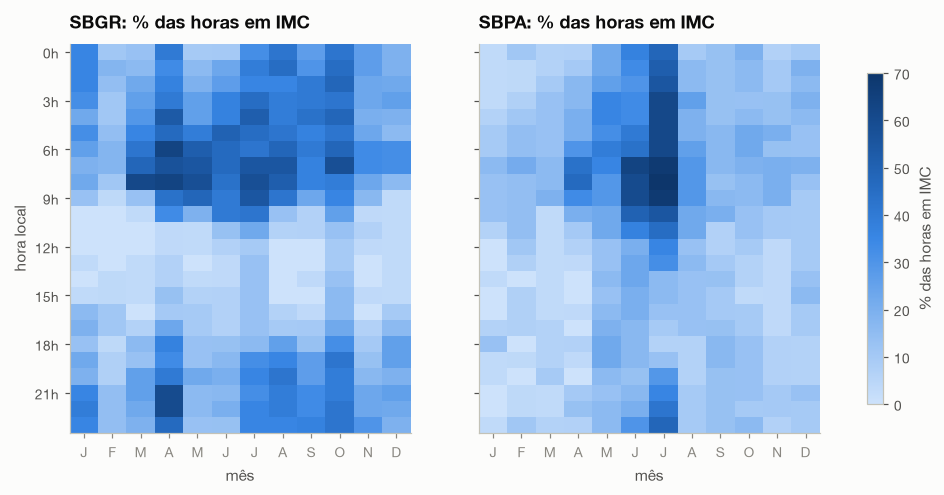

In [15]:
fig, eixos = plt.subplots(1, 2, figsize=(11, 4.6), sharey=True)
for ax, icao in zip(eixos, ["SBGR", "SBPA"]):
    tab = metar[metar["icao"] == icao].pivot_table(index="hora_local", columns="mes", values="imc", aggfunc="mean") * 100
    im = ax.imshow(tab, aspect="auto", cmap=SEQ, vmin=0, vmax=70, origin="upper")
    ax.set_title(f"{icao}: % das horas em IMC")
    ax.set_xticks(range(12), ["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
    ax.set_yticks(range(0, 24, 3), [f"{h}h" for h in range(0, 24, 3)])
    ax.set_xlabel("mês")
    ax.grid(False)
eixos[0].set_ylabel("hora local")
fig.colorbar(im, ax=eixos, shrink=0.85, label="% das horas em IMC")
plt.show()

**Leitura:** Guarulhos tem IMC concentrado **da meia-noite ao meio da manhã** (nevoeiro e teto baixo noturnos) o ano todo, que some à tarde. Porto Alegre tem um padrão **sazonal**: o nevoeiro de inverno (jun–jul). Padrão forte e repetitivo é exatamente o que um modelo consegue aprender.

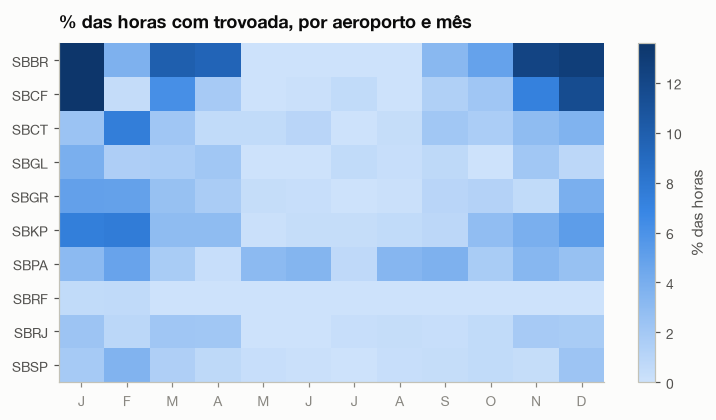

In [16]:
tab = metar.pivot_table(index="icao", columns="mes", values="trovoada", aggfunc="mean") * 100
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(tab, aspect="auto", cmap=SEQ, vmin=0)
ax.set_xticks(range(12), ["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
ax.set_yticks(range(len(tab)), tab.index)
ax.grid(False)
ax.set_title("% das horas com trovoada, por aeroporto e mês")
fig.colorbar(im, ax=ax, label="% das horas")
plt.show()

**Leitura:** trovoada é fenômeno de **verão** (nov–mar) no Sudeste e Centro-Oeste, com Brasília no topo. Recife quase não tem. Ou seja, o "tempo ruim" muda de natureza conforme o aeroporto e a estação: nevoeiro no inverno, trovoada no verão.

## 6. Voos: pontualidade em 2025 (VRA da ANAC)

Filtro: voos **regulares** (código DI = 0), **domésticos de passageiros** (tipo de linha N). Atrasado = partida real mais de 30 min depois da prevista (mesmo critério dos relatórios da ANAC).

> **Fuso horário:** o VRA não diz o fuso. As durações de ida e volta GRU–Manaus são iguais (240 e 235 min), então todos os horários estão num fuso só, e não no local de cada aeroporto. Testando o cruzamento com o clima nas seções seguintes, o alinhamento com **horário de Brasília (UTC−3)** dá associações bem mais fortes do que tratar como UTC. É o que a ANAC documenta.

In [17]:
voos = voos_regulares_domesticos(carregar_vra())
voos["mes"] = voos["partida_prev"].dt.month
voos["hora"] = voos["partida_prev"].dt.hour
voos["dia"] = voos["partida_prev"].dt.normalize()
print(f"{len(voos):,} voos | cancelados {voos['cancelado'].mean():.1%} | atraso > 30 min {voos['atrasado_30'].mean():.1%}".replace(",", "."))
voos.groupby("empresa").agg(voos=("voo", "size"), atraso_30=("atrasado_30", "mean"), cancelados=("cancelado", "mean")) \
    .query("voos > 5000").sort_values("voos", ascending=False).style.format({"voos": "{:,.0f}", "atraso_30": "{:.1%}", "cancelados": "{:.1%}"})

783.306 voos | cancelados 1.7% | atraso > 30 min 7.2%


,voos,atraso_30,cancelados
empresa,,,
AZU,"281,422",7.7%,1.4%
TAM,"263,748",7.6%,1.7%
GLO,"218,399",5.9%,1.1%
ACN,"15,628",10.4%,13.5%


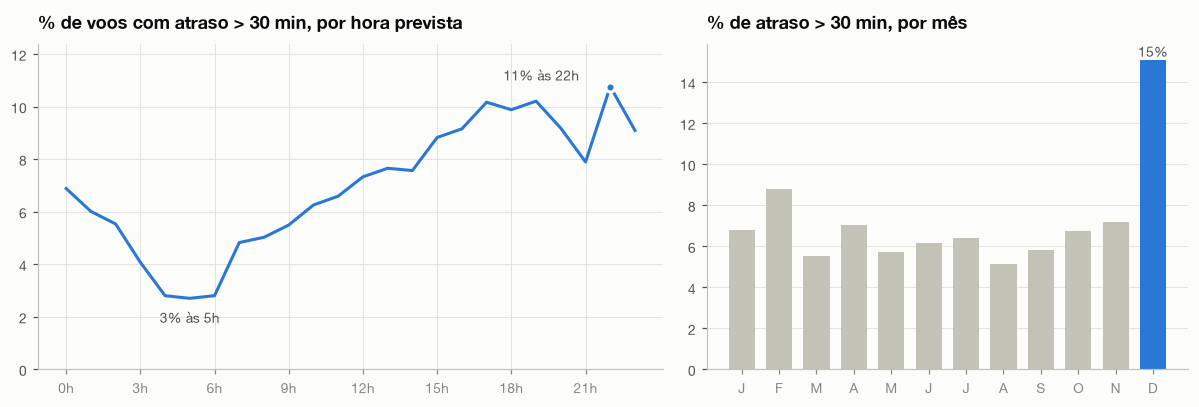

In [18]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={"width_ratios": [1.3, 1]})
por_hora = voos.groupby("hora")["atrasado_30"].mean() * 100
a1.plot(por_hora.index, por_hora.values, color=AZUL, linewidth=2)
a1.scatter(por_hora.idxmax(), por_hora.max(), color=AZUL, s=36, zorder=3, edgecolor=FUNDO, linewidth=2)
a1.annotate(f"{por_hora.max():.0f}% às {por_hora.idxmax()}h", (por_hora.idxmax(), por_hora.max()), xytext=(-70, 4),
            textcoords="offset points", fontsize=9, color=TINTA2)
a1.annotate(f"{por_hora.min():.0f}% às {por_hora.idxmin()}h", (por_hora.idxmin(), por_hora.min()), xytext=(0, -16),
            textcoords="offset points", fontsize=9, color=TINTA2, ha="center")
a1.set_xticks(range(0, 24, 3), [f"{h}h" for h in range(0, 24, 3)])
a1.set_ylim(0, por_hora.max() * 1.15)
a1.set_title("% de voos com atraso > 30 min, por hora prevista")

por_mes = voos.groupby("mes")["atrasado_30"].mean() * 100
a2.bar(por_mes.index, por_mes.values, color=[AZUL if m == 12 else CINZA for m in por_mes.index], width=0.7)
a2.text(12, por_mes[12], f"{por_mes[12]:.0f}%", ha="center", va="bottom", fontsize=9, color=TINTA2)
a2.set_xticks(range(1, 13), ["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
a2.grid(axis="x", visible=False)
a2.set_title("% de atraso > 30 min, por mês")
plt.tight_layout()
plt.show()

**Leitura:**
- O atraso **acumula ao longo do dia**: os primeiros voos da manhã saem no horário e cada atraso empurra os voos seguintes da mesma aeronave e tripulação. É a **propagação de atraso**.
- **Dezembro** destoa de todos os meses. Vamos ver dia a dia:

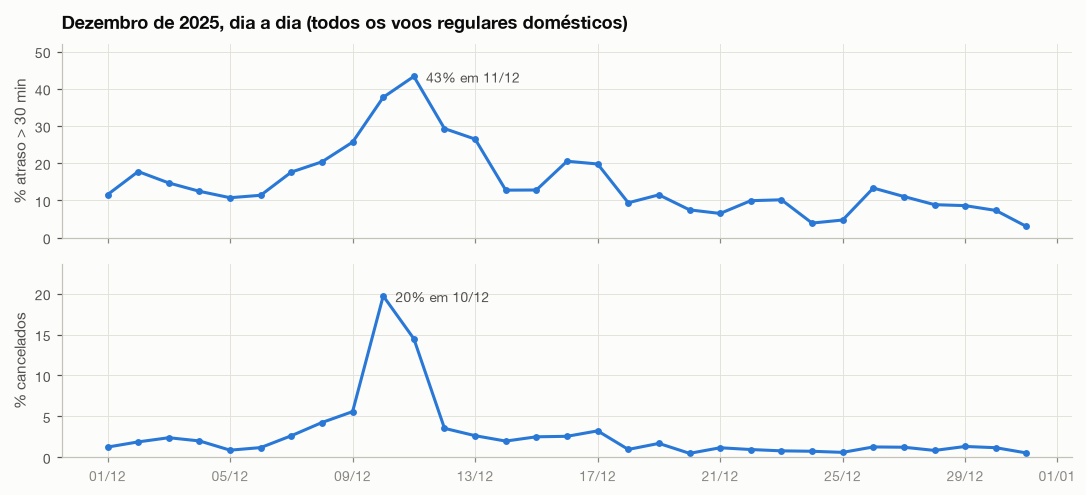

In [19]:
dez = voos[voos["mes"] == 12].groupby("dia")[["atrasado_30", "cancelado"]].mean() * 100
fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 4.6), sharex=True)
for ax, col, nome in [(a1, "atrasado_30", "atraso > 30 min"), (a2, "cancelado", "cancelados")]:
    ax.plot(dez.index, dez[col], color=AZUL, linewidth=2, marker="o", markersize=3.5)
    pico = dez[col].idxmax()
    ax.annotate(f"{dez[col].max():.0f}% em {pico:%d/%m}", (pico, dez[col].max()), xytext=(8, -4),
                textcoords="offset points", fontsize=9, color=TINTA2)
    ax.set_ylabel(f"% {nome}")
    ax.set_ylim(0, dez[col].max() * 1.2)
a1.set_title("Dezembro de 2025, dia a dia (todos os voos regulares domésticos)")
a2.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
plt.tight_layout()
plt.show()

A semana de **8 a 13/12** concentra o problema: os cancelamentos chegam ao pico em **10/12** e os atrasos no dia seguinte, enquanto a malha se recupera. A seção 7.2 mostra o que aconteceu.

## 7. Cruzando voo × clima

Cada partida recebe o METAR da **origem** na hora prevista (em UTC) e o METAR do **destino** na mesma hora, quando o destino também é um dos 10 aeroportos. Usar o METAR do destino na hora da *chegada* seria olhar o futuro.

In [20]:
COLS_CLIMA = ["imc", "abaixo_minimos", "trovoada", "nevoeiro", "chuva", "vis_m", "teto_ft", "vento_kt", "rajada_kt"]


def juntar_clima(voos, metar, deslocamento_h=3):
    v = voos[voos["origem"].isin(AEROPORTOS)].copy()
    v["hora_utc"] = (v["partida_prev"] + pd.Timedelta(hours=deslocamento_h)).dt.floor("h")
    w = metar[["icao", "hora_utc"] + COLS_CLIMA]
    for lado, chave in [("o", "origem"), ("d", "destino")]:
        renomeado = w.rename(columns={c: f"{lado}_{c}" for c in COLS_CLIMA} | {"icao": chave})
        v = v.merge(renomeado, on=[chave, "hora_utc"], how="left")
    clima = [f"{l}_{c}" for l in ("o", "d") for c in COLS_CLIMA]
    v[clima] = v[clima].astype(float)
    return v


# Checagem do fuso: com +3 h (Brasília -> UTC) a relação clima x atraso fica bem mais forte do que com 0 h
for desloc in [0, 3]:
    t = juntar_clima(voos, metar, desloc)
    print(f"deslocamento +{desloc}h -> atraso com trovoada na origem: {t.loc[t['o_trovoada'] == True, 'atrasado_30'].mean():.1%}, "
          f"cancelamento abaixo dos mínimos: {t.loc[t['o_abaixo_minimos'] == True, 'cancelado'].mean():.1%}")

vc = juntar_clima(voos, metar)
print(f"{len(vc):,} partidas dos 10 aeroportos, {vc['o_imc'].notna().mean():.1%} com METAR da origem".replace(",", "."))

deslocamento +0h -> atraso com trovoada na origem: 15.1%, cancelamento abaixo dos mínimos: 5.9%
deslocamento +3h -> atraso com trovoada na origem: 18.3%, cancelamento abaixo dos mínimos: 7.9%
509.670 partidas dos 10 aeroportos. 100.0% com METAR da origem


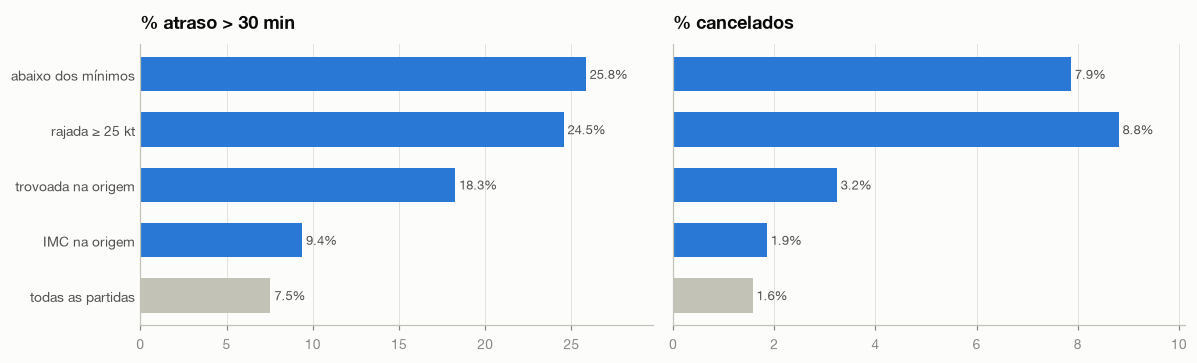

,partidas,atraso > 30 min,cancelados
todas as partidas,"509,590",7.5%,1.6%
IMC na origem,"68,274",9.4%,1.9%
rajada ≥ 25 kt,"3,100",24.5%,8.8%
trovoada na origem,"11,591",18.3%,3.2%
abaixo dos mínimos,"1,475",25.8%,7.9%


In [21]:
condicoes = {
    "todas as partidas": vc["o_imc"].notna(),
    "IMC na origem": vc["o_imc"] == True,
    "rajada ≥ 25 kt": vc["o_rajada_kt"] >= 25,
    "trovoada na origem": vc["o_trovoada"] == True,
    "abaixo dos mínimos": vc["o_abaixo_minimos"] == True,
}
efeito = pd.DataFrame({
    nome: {"partidas": m.sum(), "atraso > 30 min": vc.loc[m, "atrasado_30"].mean() * 100,
           "cancelados": vc.loc[m, "cancelado"].mean() * 100}
    for nome, m in condicoes.items()
}).T

fig, eixos = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
for ax, col in zip(eixos, ["atraso > 30 min", "cancelados"]):
    s = efeito[col]
    cores = [CINZA if i == "todas as partidas" else AZUL for i in s.sort_values().index]
    barras_h(ax, s, fmt="{:.1f}%", cores=cores)
    ax.set_title(f"% {col}")
plt.tight_layout()
plt.show()
efeito.style.format({"partidas": "{:,.0f}", "atraso > 30 min": "{:.1f}%", "cancelados": "{:.1f}%"})

**Leitura:** cada condição adversa na origem **multiplica** a chance de atraso e cancelamento em relação à média (cinza). Abaixo dos mínimos ou com rajada forte, o cancelamento fica ~5× maior. IMC sozinho pesa pouco, porque o aeroporto continua operando por instrumentos. A relação é forte, tem explicação física e operacional, e envolve dezenas de milhares de voos. É uma base sólida para um modelo supervisionado.

### 7.2 O caso de 10/12/2025: vento com céu limpo

In [22]:
bruto = pd.read_csv(RAW_DATA_DIR / "metar/SBSP.csv")
display(bruto[bruto["valid"].between("2025-12-10 12:00", "2025-12-10 21:00") & bruto["valid"].str.endswith(":00")]
        [["valid", "metar"]].rename(columns={"valid": "hora UTC"}))

dia = vc[vc["dia"] == "2025-12-10"].groupby("origem")[["atrasado_30", "cancelado", "o_rajada_kt", "o_trovoada"]] \
    .agg({"atrasado_30": "mean", "cancelado": "mean", "o_rajada_kt": "max", "o_trovoada": "mean"})
dia.columns = ["atraso > 30 min", "cancelados", "rajada máx (kt)", "% horas c/ trovoada"]
dia.sort_values("cancelados", ascending=False).style.format(
    {"atraso > 30 min": "{:.0%}", "cancelados": "{:.0%}", "rajada máx (kt)": "{:.0f}", "% horas c/ trovoada": "{:.0%}"})

,hora UTC,metar
10750,2025-12-10 12:00,SBSP 101200Z 31023G37KT 280V350 9999 BKN026 23/17 Q1006
10751,2025-12-10 13:00,SBSP 101300Z 31021G33KT 9999 BKN033 24/16 Q1007
10752,2025-12-10 14:00,SBSP 101400Z 32023G37KT 280V340 9999 SCT036 BKN040 25/16 Q1006
10753,2025-12-10 15:00,SBSP 101500Z 32029G52KT 9999 SCT040 SCT066 25/15 Q1006
10754,2025-12-10 16:00,SBSP 101600Z 31023G40KT 290V350 9999 SCT046 27/15 Q1005
10755,2025-12-10 17:00,SBSP 101700Z 32025G42KT 290V360 9999 FEW046 27/16 Q1004
10756,2025-12-10 18:00,SBSP 101800Z 32030G42KT 9999 FEW046 27/15 Q1003
10757,2025-12-10 19:00,SBSP 101900Z 32024G38KT CAVOK 28/16 Q1003
10758,2025-12-10 20:00,SBSP 102000Z 32024G38KT 280V340 CAVOK 27/15 Q1003
10759,2025-12-10 21:00,SBSP 102100Z 32021G35KT CAVOK 26/16 Q1004


,atraso > 30 min,cancelados,rajada máx (kt),% horas c/ trovoada
origem,,,,
SBSP,33%,42%,52,0%
SBRJ,42%,36%,nan,0%
SBPA,39%,29%,24,0%
SBGR,49%,19%,42,0%
SBCT,44%,18%,49,0%
SBCF,37%,16%,nan,11%
SBRF,28%,12%,nan,0%
SBBR,39%,12%,23,0%
SBGL,47%,11%,33,0%


**Leitura:** em Congonhas (SBSP) o METAR mostra vento de 20–30 kt com **rajadas de até 52 kt (~96 km/h, às 15 UTC)** a tarde inteira, mas **visibilidade de 10 km, sem chuva e sem trovoada**, e no fim da tarde CAVOK. Pelas flags de "tempo ruim" (IMC, trovoada), seria um dia bom. Congonhas cancelou 42% dos voos. A ventania pegou também Guarulhos (42 kt) e Curitiba (49 kt), mas aeroportos **sem vento nenhum** sofreram igual: Santos Dumont cancelou 36%, e todos os 10 aeroportos tiveram 28–58% de atraso.

Isso traz duas lições para o modelo:
1. "Tempo ruim" não é só visibilidade e trovoada: **vento/rajada** precisa entrar como variável.
2. O problema é de **rede**: uma pane num hub (SP) se espalha pela malha. Variáveis como "o que está acontecendo no hub agora" ou "atraso recente do aeroporto" carregam isso.

## 8. Teste de viabilidade dos modelos

Não é o modelo final. É só para saber se o sinal existe e quanto cada grupo de variáveis contribui.

### 8.1 Prever atraso e cancelamento de um voo

- **Divisão temporal:** treino de jan–set, teste de out–dez. Dividir aleatoriamente deixaria o modelo "ver o futuro".
- **Informação disponível no início da hora de partida:** METAR atual da origem e do destino, e a taxa de atraso das partidas da origem **2 e 3 horas antes** (as da hora anterior ainda não se sabe se vão atrasar).
- **Métricas:** ROC-AUC (0,5 = chute) e PR-AUC, que é mais informativa em classe rara. Para PR-AUC, o chute vale a prevalência.

In [23]:
# Propagação: % de partidas atrasadas na origem em horas anteriores
taxa_hora = vc.groupby(["origem", "hora_utc"])["atrasado_30"].mean().rename("taxa").reset_index()
for lag in [2, 3]:
    t = taxa_hora.assign(hora_utc=taxa_hora["hora_utc"] + pd.Timedelta(hours=lag)).rename(columns={"taxa": f"atraso_origem_lag{lag}"})
    vc = vc.merge(t, on=["origem", "hora_utc"], how="left")
vc["partidas_previstas_hora"] = vc.groupby(["origem", "hora_utc"])["voo"].transform("size")
vc["dia_semana"] = vc["partida_prev"].dt.dayofweek

CAT = ["empresa", "origem", "destino", "aeronave"]
for c in CAT:
    vc[c] = vc[c].astype("category")
CLIMA = [f"{l}_{c}" for l in ("o", "d") for c in COLS_CLIMA]

CONJUNTOS = {
    "programação (empresa, rota, horário, avião)": CAT + ["mes", "dia_semana", "hora", "partidas_previstas_hora", "assentos"],
}
CONJUNTOS["+ clima (METAR origem e destino)"] = CONJUNTOS["programação (empresa, rota, horário, avião)"] + CLIMA
CONJUNTOS["+ propagação (atraso recente da origem)"] = CONJUNTOS["+ clima (METAR origem e destino)"] + ["atraso_origem_lag2", "atraso_origem_lag3"]

treino, teste = vc[vc["mes"] <= 9], vc[vc["mes"] >= 10]
print(f"treino: {len(treino):,} voos | teste: {len(teste):,} voos".replace(",", "."))

resultados = []
for alvo in ["atrasado_30", "cancelado"]:
    for nome, cols in CONJUNTOS.items():
        modelo = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.08, categorical_features="from_dtype", random_state=0)
        modelo.fit(treino[cols], treino[alvo])
        p = modelo.predict_proba(teste[cols])[:, 1]
        resultados.append({"alvo": alvo, "variáveis": nome, "ROC-AUC": roc_auc_score(teste[alvo], p),
                           "PR-AUC": average_precision_score(teste[alvo], p), "PR-AUC do chute": teste[alvo].mean()})
pd.DataFrame(resultados).set_index(["alvo", "variáveis"]).round(3)

treino: 380.309 voos | teste: 129.361 voos


ROC-AUC  PR-AUC  PR-AUC do chute
alvo        variáveis                                                                    
atrasado_30 programação (empresa, rota, horário, avião)    0.628   0.162            0.106
            + clima (METAR origem e destino)               0.659   0.189            0.106
            + propagação (atraso recente da origem)        0.724   0.285            0.106
cancelado   programação (empresa, rota, horário, avião)    0.669   0.046            0.017
            + clima (METAR origem e destino)               0.691   0.051            0.017
            + propagação (atraso recente da origem)        0.745   0.069            0.017

**Leitura:**
- Só com a programação do voo, o modelo já é melhor que o chute. Empresa, aeroporto e horário carregam padrão.
- O **clima** acrescenta ganho real, mas moderado. Lembre que o METAR mede o clima *no momento*; um modelo que preveja com horas de antecedência teria que usar a **previsão** (TAF), que também está na API `met` da AISWEB e na REDEMET.
- A **propagação** é o maior salto. Isso confirma o que os gráficos mostraram: o atraso de agora é o melhor indicador do atraso daqui a pouco.
- Há muito espaço para melhorar (o modelo não sabe, por exemplo, que aeronave faz qual voo), o que é bom para o trabalho: dá para mostrar evolução entre um baseline e o modelo final.

### 8.2 Prever o próprio clima: IMC 3 horas à frente

Para cada aeroporto, prever se daqui a 3 h estará em IMC usando o METAR atual e as variações das últimas horas (queda da visibilidade, aproximação entre temperatura e ponto de orvalho...). O baseline é a **persistência**: "daqui a 3 h vai estar igual a agora".

In [24]:
VARS_METAR = ["vis_m", "teto_ft", "vento_kt", "vento_dir", "temp_c", "orvalho_c", "qnh", "imc", "nevoeiro", "nevoa", "chuva", "trovoada"]
HORIZONTE = 3

linhas = []
for icao in ["SBGR", "SBSP", "SBCT", "SBPA"]:
    s = metar[metar["icao"] == icao].set_index("hora_utc").sort_index()[VARS_METAR].astype(float).asfreq("h")
    s["spread"] = s["temp_c"] - s["orvalho_c"]  # ar perto da saturação -> nevoeiro
    for k in [1, 3]:
        for c in ["vis_m", "teto_ft", "spread", "qnh", "temp_c"]:
            s[f"{c}_var{k}h"] = s[c] - s[c].shift(k)
    s["hora"], s["mes"] = s.index.hour, s.index.month
    s["alvo"] = s["imc"].shift(-HORIZONTE)
    s = s.dropna(subset=["alvo", "imc"])
    tr, te = s[s["mes"] <= 9], s[s["mes"] >= 10]
    feats = [c for c in s.columns if c != "alvo"]
    p = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, random_state=0).fit(tr[feats], tr["alvo"]).predict_proba(te[feats])[:, 1]
    linhas.append({"aeroporto": icao, "% horas IMC (teste)": te["alvo"].mean(),
                   "ROC-AUC modelo": roc_auc_score(te["alvo"], p), "ROC-AUC persistência": roc_auc_score(te["alvo"], te["imc"]),
                   "F1 modelo": f1_score(te["alvo"], p > 0.5), "F1 persistência": f1_score(te["alvo"], te["imc"])})
pd.DataFrame(linhas).set_index("aeroporto").round(3)

,% horas IMC (teste),ROC-AUC modelo,ROC-AUC persistência,F1 modelo,F1 persistência
aeroporto,,,,,
SBGR,0.222,0.878,0.758,0.609,0.624
SBSP,0.259,0.875,0.761,0.680,0.646
SBCT,0.455,0.904,0.810,0.811,0.794
SBPA,0.117,0.895,0.803,0.625,0.650


**Leitura:** o modelo **ordena** bem o risco (ROC-AUC alto, bem acima da persistência), mas, quando se olha o acerto sim/não (F1), fica empatado com a persistência. É o resultado clássico de nowcasting: o tempo muda devagar, então "repetir o agora" já é um baseline forte. Prever **mudanças** (entrada e saída de nevoeiro) é o problema difícil e interessante. Funciona como trabalho, mas exige mais cuidado com a métrica.

## 9. Situações-problema candidatas

| | Situação-problema | Tarefa de ML | Dados | Evidência neste notebook | Riscos / cuidados |
|---|---|---|---|---|---|
| **A** ⭐ | Companhias e passageiros só descobrem que o voo vai atrasar ou ser cancelado em cima da hora. Dá para **estimar o risco de cada voo** com base no clima e no estado da malha? | Classificação binária desbalanceada (atraso > 30 min; cancelamento) | VRA (ANAC) + METAR/TAF (DECEA/REDEMET) | Clima adverso multiplica o atraso por 2,5–3,5×; baseline com ROC-AUC ~0,72 e muito espaço para evoluir; ~780 mil voos/ano | Desbalanceamento (7% / 1,7%); usar previsão (TAF), não o METAR observado, se o modelo for para horas antes |
| **B** | Teto baixo e nevoeiro reduzem a capacidade das pistas e o CGNA precisa planejar o fluxo com antecedência. Dá para **prever IMC/nevoeiro em um aeroporto** nas próximas horas? | Classificação em série temporal (nowcasting) | METAR histórico (REDEMET ou IEM) | Padrões fortes por hora e estação (GRU: madrugada; POA: inverno); AUC ~0,88 | Persistência é baseline difícil; a métrica certa é acertar as **mudanças** de condição |
| **C** | Pilotos recebem dezenas de NOTAMs por voo (*NOTAM overload*) e parte deles vem com código errado. Dá para **classificar automaticamente** os NOTAMs pelo texto e apontar inconsistências? | Classificação de texto (NLP) multiclasse | AISWEB `notam` | Metade das "áreas perigosas" codificadas como `XX`; F1 ≈ 0,95 | Base pequena (~800 textos únicos) e padronizada, quase fácil demais; precisa coletar por semanas |
| **D** | Que **tipos de dia** de disrupção existem na malha (tempestade de verão, nevoeiro de inverno, ventania, pane de hub)? | Agrupamento (clustering) de dias × aeroportos | VRA + METAR | Caso de 10/12 (vento + efeito em rede) | Não supervisionado, então mais difícil de "provar" que funcionou |

### Recomendação

**A** é a mais completa para um trabalho de faculdade:
- o problema é concreto e fácil de explicar (quem nunca teve voo atrasado?);
- a base é grande, pública e real;
- tem variável-alvo clara e mensurável;
- a relação causal com os dados do DECEA é demonstrável (seção 7);
- existe um baseline honesto para comparar evolução (seção 8.1).

Também dá para usar a **B** como etapa da **A** (prever o tempo e, com isso, o atraso), ou a **C** como análise complementar dos dados da AISWEB.

### Próximos passos se escolher a A
1. Pedir a chave da **API REDEMET** e trocar o IEM pela fonte oficial; incluir o **TAF** como variável (previsão disponível horas antes).
2. Ampliar para 2023–2025 (VRA e METAR) para ter mais eventos raros (abaixo dos mínimos, ventania).
3. Variáveis de rede: atraso recente nos hubs (GRU, CGH, BSB), clima no destino, número de voos programados.
4. Comparar modelos (regressão logística → árvores → gradient boosting) com validação temporal, e analisar importâncias/SHAP para explicar **por que** o voo é de risco.